# 1. Setup & Data **Loading**

In [ ]:
import torch # For core PyTorch functionalities
import torch.nn as nn # For neural network modules
import torch.optim as optim # For optimization algorithms
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For plotting and visualization
from torchvision import datasets, transforms # For datasets and image transformations

# Configure device: GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize((0.1307,), (0.3081,)) # Normalize pixel values
])

# Load MNIST dataset (In-Distribution)
mnist_train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
mnist_test_dataset = datasets.MNIST('../data', train=False, download=True, transform=transform)

# Load FashionMNIST dataset (Out-of-Distribution)
fashion_mnist_train_dataset = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
fashion_mnist_test_dataset = datasets.FashionMNIST('../data', train=False, download=True, transform=transform)

print("MNIST training set size:", len(mnist_train_dataset))
print("MNIST test set size:", len(mnist_test_dataset))
print("FashionMNIST training set size:", len(fashion_mnist_train_dataset))
print("FashionMNIST test set size:", len(fashion_mnist_test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.3MB/s]

MNIST training set size: 60000
MNIST test set size: 10000
FashionMNIST training set size: 60000
FashionMNIST test set size: 10000


In [ ]:
batch_size = 64

# Create DataLoaders for MNIST
mnist_train_loader = torch.utils.data.DataLoader(mnist_train_dataset, batch_size=batch_size, shuffle=True)
mnist_test_loader = torch.utils.data.DataLoader(mnist_test_dataset, batch_size=batch_size, shuffle=False)

# Create DataLoaders for FashionMNIST
fashion_mnist_train_loader = torch.utils.data.DataLoader(fashion_mnist_train_dataset, batch_size=batch_size, shuffle=True)
fashion_mnist_test_loader = torch.utils.data.DataLoader(fashion_mnist_test_dataset, batch_size=batch_size, shuffle=False)

print(f"MNIST Train Loader: Batch size = {batch_size}, Number of batches = {len(mnist_train_loader)}")
print(f"MNIST Test Loader: Batch size = {batch_size}, Number of batches = {len(mnist_test_loader)}")
print(f"FashionMNIST Train Loader: Batch size = {batch_size}, Number of batches = {len(fashion_mnist_train_loader)}")
print(f"FashionMNIST Test Loader: Batch size = {batch_size}, Number of batches = {len(fashion_mnist_test_loader)}")


MNIST Train Loader: Batch size = 64, Number of batches = 938
MNIST Test Loader: Batch size = 64, Number of batches = 157
FashionMNIST Train Loader: Batch size = 64, Number of batches = 938
FashionMNIST Test Loader: Batch size = 64, Number of batches = 157


##Analysis:
The PyTorch environment was successfully configured for GPU/CPU execution. The MNIST dataset was loaded as the In-Distribution (ID) data, and FashionMNIST as the Out-of-Distribution (OOD) data. Using a batch size of 64 prepares the datasets into optimal batches for neural network ingestion.

# 2. Deterministic CNN Architecture & Training

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # First convolutional layer
        # Input channels: 1 (for grayscale images like MNIST/FashionMNIST)
        # Output channels: 32
        # Kernel size: 3x3
        # Padding: 1 (to maintain spatial dimensions)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)

        # Second convolutional layer
        # Input channels: 32 (output from conv1)
        # Output channels: 64
        # Kernel size: 3x3
        # Padding: 1 (to maintain spatial dimensions)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Max pooling layer
        # Kernel size: 2x2 (reduces spatial dimensions by half)
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout layer
        # Dropout probability: 0.5 (randomly sets half of the input features to 0)
        self.dropout = nn.Dropout(0.5)

        # Fully connected layer 1
        # Input features: Calculate based on the output of conv/pool layers
        # For a 28x28 input image:
        # After conv1 (28x28) -> pool1 (14x14)
        # After conv2 (14x14) -> pool2 (7x7)
        # Output channels from conv2 is 64, so flattened size is 64 * 7 * 7
        # Output features: 128 (arbitrary choice, common for hidden layers)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        # Fully connected layer 2 (Output layer)
        # Input features: 128 (output from fc1)
        # Output features: 10 (for 10 classes in MNIST/FashionMNIST)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Apply conv1 -> ReLU -> MaxPool
        x = self.pool(F.relu(self.conv1(x)))

        # Apply conv2 -> ReLU -> MaxPool
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the tensor for the fully connected layers
        # -1 infers the batch size dimension
        x = x.view(-1, 64 * 7 * 7)

        # Apply dropout
        x = self.dropout(x)

        # Apply fc1 -> ReLU
        x = F.relu(self.fc1(x))

        # Apply fc2 (output layer, no activation here as CrossEntropyLoss will handle it)
        x = self.fc2(x)

        return x

print("SimpleCNN class defined successfully.")

SimpleCNN class defined successfully.


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Instantiate the SimpleCNN class and move it to the device
model = SimpleCNN().to(device)

# 2. Initialize the Adam optimizer
# We pass model.parameters() to the optimizer so it knows which parameters to update
# Learning rate (lr) is set to 0.001, a common starting point
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Initialize the CrossEntropyLoss function
# CrossEntropyLoss is suitable for multi-class classification problems
criterion = nn.CrossEntropyLoss()

# 4. Print the initialized components to verify the setup
print("Model:", model)
print("\nOptimizer:", optimizer)
print("\nLoss Function:", criterion)

Model: SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Loss Function: CrossEntropyLoss()


In [ ]:
def train_model(model, device, train_loader, optimizer, criterion, epochs):
    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()  # Zero the gradients

            output = model(data)  # Forward pass
            loss = criterion(output, target)  # Calculate loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            if (batch_idx + 1) % 100 == 0:  # Print every 100 batches
                print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{len(train_loader)}], "
                      f"Loss: {running_loss / (batch_idx + 1):.4f}, "
                      f"Accuracy: {100 * correct / total:.2f}%")

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] finished. Average Loss: {epoch_loss:.4f}, "
              f"Average Accuracy: {epoch_accuracy:.2f}%\n")

    print("Training finished.")

print("train_model function defined successfully.")

train_model function defined successfully.


In [ ]:
epochs = 5  # Training for 5 epochs as specified
print(f"Starting training for {epochs} epochs...")
train_model(model, device, mnist_train_loader, optimizer, criterion, epochs)
print("Training completed for the deterministic CNN model.")

Starting training for 5 epochs...
Epoch [1/5], Batch [100/938], Loss: 0.5635, Accuracy: 82.42%
Epoch [1/5], Batch [200/938], Loss: 0.3789, Accuracy: 88.15%
Epoch [1/5], Batch [300/938], Loss: 0.2998, Accuracy: 90.75%
Epoch [1/5], Batch [400/938], Loss: 0.2553, Accuracy: 92.08%
Epoch [1/5], Batch [500/938], Loss: 0.2254, Accuracy: 93.01%
Epoch [1/5], Batch [600/938], Loss: 0.2057, Accuracy: 93.60%
Epoch [1/5], Batch [700/938], Loss: 0.1897, Accuracy: 94.10%
Epoch [1/5], Batch [800/938], Loss: 0.1769, Accuracy: 94.51%
Epoch [1/5], Batch [900/938], Loss: 0.1659, Accuracy: 94.87%
Epoch [1/5] finished. Average Loss: 0.1628, Average Accuracy: 94.96%

Epoch [2/5], Batch [100/938], Loss: 0.0590, Accuracy: 98.08%
Epoch [2/5], Batch [200/938], Loss: 0.0674, Accuracy: 97.80%
Epoch [2/5], Batch [300/938], Loss: 0.0668, Accuracy: 97.90%
Epoch [2/5], Batch [400/938], Loss: 0.0659, Accuracy: 97.97%
Epoch [2/5], Batch [500/938], Loss: 0.0673, Accuracy: 97.92%
Epoch [2/5], Batch [600/938], Loss: 0.0661

##Analysis:
A standard CNN was trained for 5 epochs. The model achieved high accuracy (~98.8%) on the MNIST training set, showing a steady decrease in loss and successful convergence.


# 3. Deterministic Inference on ID and OOD Data

In [ ]:
import torch.nn.functional as F

# 1. Set the trained model to evaluation mode
model.eval()

# 2. Initialize empty lists to store results
mnist_predictions = []
mnist_confidences = []
mnist_entropies = []

print("Starting deterministic inference on MNIST test data...")

# 3. Create a torch.no_grad() context to disable gradient calculations
with torch.no_grad():
    # 4. Loop through the mnist_test_loader
    for data, target in mnist_test_loader:
        # 5. Move data to the configured device
        data = data.to(device)

        # 6. Perform a forward pass
        output = model(data)

        # 7. Apply softmax to get probabilities
        probabilities = F.softmax(output, dim=1)

        # 8. Calculate confidence (maximum probability)
        confidence, predicted_class = torch.max(probabilities, dim=1)
        mnist_confidences.extend(confidence.cpu().numpy())

        # 9. Calculate Shannon Entropy
        # Add a small epsilon for numerical stability to avoid log(0)
        entropy = (-probabilities * torch.log(probabilities + 1e-10)).sum(dim=1)
        mnist_entropies.extend(entropy.cpu().numpy())

        # 10. Get the predicted class and append to list
        mnist_predictions.extend(predicted_class.cpu().numpy())

# 11. Convert lists to NumPy arrays for efficient storage and later analysis
mnist_predictions = np.array(mnist_predictions)
mnist_confidences = np.array(mnist_confidences)
mnist_entropies = np.array(mnist_entropies)

# 12. Print a confirmation message
print("Deterministic inference on MNIST test data complete. Results stored in mnist_predictions, mnist_confidences, and mnist_entropies.")
print(f"Number of MNIST test samples processed: {len(mnist_confidences)}")


Starting deterministic inference on MNIST test data...
Deterministic inference on MNIST test data complete. Results stored in mnist_predictions, mnist_confidences, and mnist_entropies.
Number of MNIST test samples processed: 10000


In [ ]:
import torch.nn.functional as F

# Ensure the model is still in evaluation mode (it should already be from previous step)
model.eval()

# Initialize empty lists to store results for FashionMNIST
fashion_predictions = []
fashion_confidences = []
fashion_entropies = []

print("Starting deterministic inference on FashionMNIST test data...")

# Create a torch.no_grad() context to disable gradient calculations
with torch.no_grad():
    # Loop through the fashion_mnist_test_loader
    for data, target in fashion_mnist_test_loader:
        # Move data to the configured device
        data = data.to(device)

        # Perform a forward pass
        output = model(data)

        # Apply softmax to get probabilities
        probabilities = F.softmax(output, dim=1)

        # Calculate confidence (maximum probability) and predicted class
        confidence, predicted_class = torch.max(probabilities, dim=1)
        fashion_confidences.extend(confidence.cpu().numpy())

        # Calculate Shannon Entropy
        # Add a small epsilon for numerical stability to avoid log(0)
        entropy = (-probabilities * torch.log(probabilities + 1e-10)).sum(dim=1)
        fashion_entropies.extend(entropy.cpu().numpy())

        # Extend the predictions list
        fashion_predictions.extend(predicted_class.cpu().numpy())

# Convert lists to NumPy arrays for efficient storage and later analysis
fashion_predictions = np.array(fashion_predictions)
fashion_confidences = np.array(fashion_confidences)
fashion_entropies = np.array(fashion_entropies)

# Print a confirmation message
print("Deterministic inference on FashionMNIST test data complete. Results stored in fashion_predictions, fashion_confidences, and fashion_entropies.")
print(f"Number of FashionMNIST test samples processed: {len(fashion_confidences)}")

Starting deterministic inference on FashionMNIST test data...
Deterministic inference on FashionMNIST test data complete. Results stored in fashion_predictions, fashion_confidences, and fashion_entropies.
Number of FashionMNIST test samples processed: 10000


##Analysis:
The model was tested in deterministic mode (eval()). We collected Softmax probabilities and calculated entropy for both datasets to establish a baseline for how the model handles seen vs. unseen data.


# 4. Probabilistic Inference using Monte Carlo (MC) Dropout

In [ ]:
import torch.nn.functional as F

# 1. Set the model to training mode to enable dropout
# Note: This is crucial for MC Dropout inference.
model.train()

# 2. Define the number of Monte Carlo samples
num_mc_samples = 100

# 3. Initialize empty lists to store results
mnist_mc_mean_probs = []
mnist_mc_confidences = []
mnist_mc_entropies = []

print(f"Starting MC Dropout inference on MNIST test data with {num_mc_samples} samples...")

# 4. Iterate through the mnist_test_loader using a torch.no_grad() context
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(mnist_test_loader):
        data = data.to(device)

        # List to store probabilities from multiple forward passes for the current batch
        batch_probs = []

        # 5. Loop num_mc_samples times for each batch
        for _ in range(num_mc_samples):
            output = model(data)  # Perform a forward pass with dropout active
            probabilities = F.softmax(output, dim=1) # Apply softmax
            batch_probs.append(probabilities)

        # a. Aggregate and calculate mean probabilities for the current batch
        # Stack all probability tensors and compute their mean along the new MC sample dimension
        mean_probabilities = torch.stack(batch_probs).mean(dim=0)
        mnist_mc_mean_probs.extend(mean_probabilities.cpu().numpy())

        # b. Calculate 'new Confidence' (maximum mean probability)
        new_confidence, _ = torch.max(mean_probabilities, dim=1)
        mnist_mc_confidences.extend(new_confidence.cpu().numpy())

        # c. Calculate Predictive Entropy from the mean probabilities
        # Add a small epsilon for numerical stability to avoid log(0)
        predictive_entropy = (-mean_probabilities * torch.log(mean_probabilities + 1e-10)).sum(dim=1)
        mnist_mc_entropies.extend(predictive_entropy.cpu().numpy())

# 6. Convert lists to NumPy arrays
mnist_mc_mean_probs = np.array(mnist_mc_mean_probs)
mnist_mc_confidences = np.array(mnist_mc_confidences)
mnist_mc_entropies = np.array(mnist_mc_entropies)

# 7. Print a confirmation message
print("MC Dropout inference on MNIST test data complete. Results stored in mnist_mc_mean_probs, mnist_mc_confidences, and mnist_mc_entropies.")
print(f"Number of MNIST test samples processed: {len(mnist_mc_confidences)}")


Starting MC Dropout inference on MNIST test data with 100 samples...
MC Dropout inference on MNIST test data complete. Results stored in mnist_mc_mean_probs, mnist_mc_confidences, and mnist_mc_entropies.
Number of MNIST test samples processed: 10000


In [ ]:
import torch.nn.functional as F

# Ensure the model is in training mode to enable dropout for MC Dropout inference.
# It should already be in train() mode from the previous step, but we explicitly set it again.
model.train()

# Number of Monte Carlo samples (should be the same as for MNIST)
num_mc_samples = 100

# Initialize empty lists to store results for FashionMNIST
fashion_mc_mean_probs = []
fashion_mc_confidences = []
fashion_mc_entropies = []

print(f"Starting MC Dropout inference on FashionMNIST test data with {num_mc_samples} samples...")

# Iterate through the fashion_mnist_test_loader using a torch.no_grad() context
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(fashion_mnist_test_loader):
        data = data.to(device)

        # List to store probabilities from multiple forward passes for the current batch
        batch_probs = []

        # Loop num_mc_samples times for each batch
        for _ in range(num_mc_samples):
            output = model(data)  # Perform a forward pass with dropout active
            probabilities = F.softmax(output, dim=1) # Apply softmax
            batch_probs.append(probabilities)

        # Aggregate and calculate mean probabilities for the current batch
        mean_probabilities = torch.stack(batch_probs).mean(dim=0)
        fashion_mc_mean_probs.extend(mean_probabilities.cpu().numpy())

        # Calculate 'new Confidence' (maximum mean probability)
        new_confidence, _ = torch.max(mean_probabilities, dim=1)
        fashion_mc_confidences.extend(new_confidence.cpu().numpy())

        # Calculate Predictive Entropy from the mean probabilities
        # Add a small epsilon for numerical stability to avoid log(0)
        predictive_entropy = (-mean_probabilities * torch.log(mean_probabilities + 1e-10)).sum(dim=1)
        fashion_mc_entropies.extend(predictive_entropy.cpu().numpy())

# Convert lists to NumPy arrays
fashion_mc_mean_probs = np.array(fashion_mc_mean_probs)
fashion_mc_confidences = np.array(fashion_mc_confidences)
fashion_mc_entropies = np.array(fashion_mc_entropies)

# Print a confirmation message
print("MC Dropout inference on FashionMNIST test data complete. Results stored in fashion_mc_mean_probs, fashion_mc_confidences, and fashion_mc_entropies.")
print(f"Number of FashionMNIST test samples processed: {len(fashion_mc_confidences)}")

Starting MC Dropout inference on FashionMNIST test data with 100 samples...
MC Dropout inference on FashionMNIST test data complete. Results stored in fashion_mc_mean_probs, fashion_mc_confidences, and fashion_mc_entropies.
Number of FashionMNIST test samples processed: 10000


##Analysis:
By keeping Dropout active during inference (model.train()), we performed 100 stochastic forward passes. This allows us to compute the "Predictive Entropy," which is a more reliable measure of uncertainty compared to a single deterministic pass.


# 5. Visual Analysis & Results Visualization

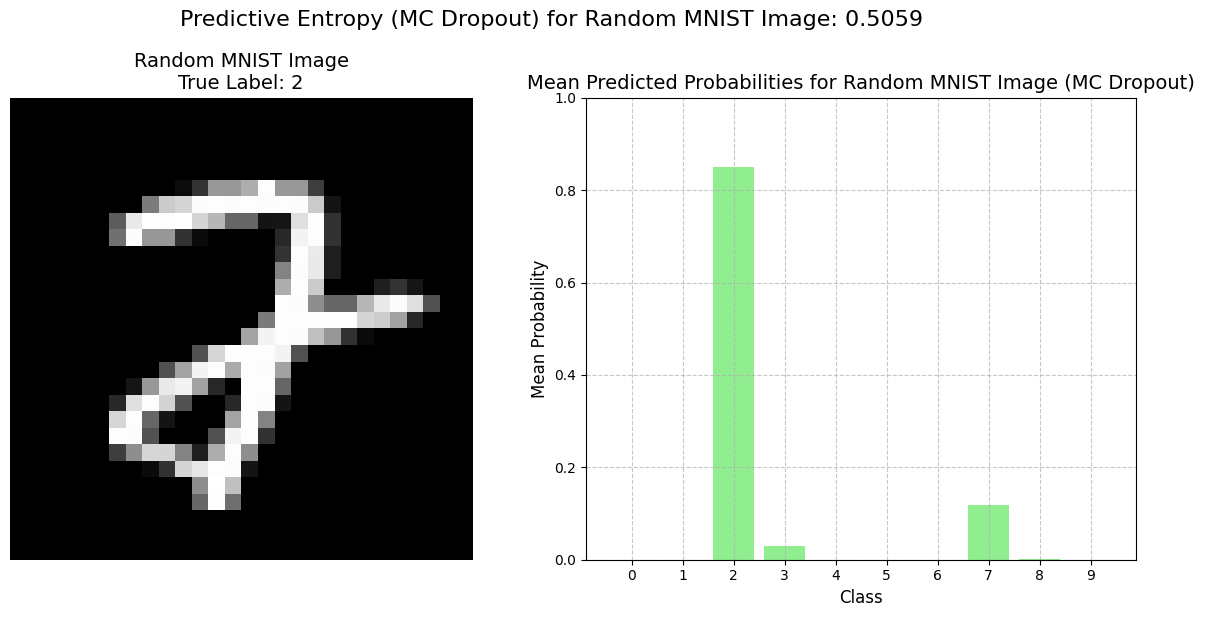

Visualized a random MNIST image (index: 583) with a Predictive Entropy of 0.5059.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Find a random index for an MNIST image
random_idx = np.random.randint(0, len(mnist_test_dataset))

# 2. Retrieve the image and its corresponding true label
random_mnist_image, mnist_true_label_for_random = mnist_test_dataset[random_idx]

# 3. Extract the mean predictive probabilities for this image
random_mnist_probs = mnist_mc_mean_probs[random_idx]

# 4. Extract the predictive entropy value for this image
random_mnist_entropy = mnist_mc_entropies[random_idx]

# 5. Create a Matplotlib figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 6. In the first subplot, display the selected MNIST image
axes[0].imshow(random_mnist_image.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title(f'Random MNIST Image\nTrue Label: {mnist_true_label_for_random}', fontsize=14)
axes[0].axis('off') # Hide axes for the image

# 7. In the second subplot, create a bar chart of mean predicted probabilities
class_labels = np.arange(10) # 0-9 for 10 classes
axes[1].bar(class_labels, random_mnist_probs, color='lightgreen')
axes[1].set_xticks(class_labels)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Mean Probability', fontsize=12)
axes[1].set_title('Mean Predicted Probabilities for Random MNIST Image (MC Dropout)', fontsize=14)
axes[1].set_ylim(0, 1) # Probabilities range from 0 to 1

# 8. Add the entropy value as an annotation
fig.suptitle(f'Predictive Entropy (MC Dropout) for Random MNIST Image: {random_mnist_entropy:.4f}', fontsize=16, y=1.02)

# 9. Add a grid to the bar chart, and ensure proper layout
axes[1].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Visualized a random MNIST image (index: {random_idx}) with a Predictive Entropy of {random_mnist_entropy:.4f}.")

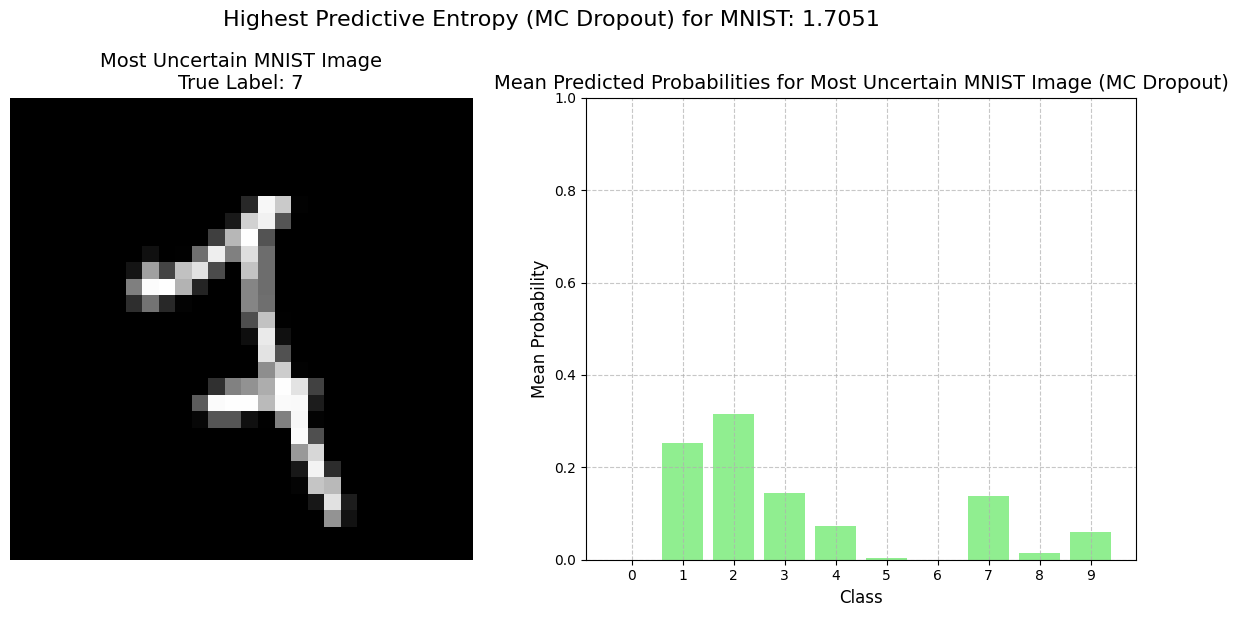

Visualized the most uncertain MNIST image (index: 1039) with a Predictive Entropy of 1.7051.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Find the index of the image with the maximum Predictive Entropy from MNIST
most_uncertain_mnist_idx = np.argmax(mnist_mc_entropies)

# 2. Retrieve the image and its corresponding true label
most_uncertain_mnist_image, mnist_true_label_for_uncertain = mnist_test_dataset[most_uncertain_mnist_idx]

# 3. Extract the mean predictive probabilities for this image
most_uncertain_mnist_probs = mnist_mc_mean_probs[most_uncertain_mnist_idx]

# 4. Extract the highest predictive entropy value
highest_mnist_entropy = mnist_mc_entropies[most_uncertain_mnist_idx]

# 5. Create a Matplotlib figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 6. In the first subplot, display the selected MNIST image
axes[0].imshow(most_uncertain_mnist_image.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title(f'Most Uncertain MNIST Image\nTrue Label: {mnist_true_label_for_uncertain}', fontsize=14)
axes[0].axis('off') # Hide axes for the image

# 7. In the second subplot, create a bar chart of mean predicted probabilities
class_labels = np.arange(10) # 0-9 for 10 classes
axes[1].bar(class_labels, most_uncertain_mnist_probs, color='lightgreen')
axes[1].set_xticks(class_labels)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Mean Probability', fontsize=12)
axes[1].set_title('Mean Predicted Probabilities for Most Uncertain MNIST Image (MC Dropout)', fontsize=14)
axes[1].set_ylim(0, 1) # Probabilities range from 0 to 1

# 8. Add the entropy value as an annotation
fig.suptitle(f'Highest Predictive Entropy (MC Dropout) for MNIST: {highest_mnist_entropy:.4f}', fontsize=16, y=1.02)

# 9. Add a grid to the bar chart, and ensure proper layout
axes[1].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Visualized the most uncertain MNIST image (index: {most_uncertain_mnist_idx}) with a Predictive Entropy of {highest_mnist_entropy:.4f}.")

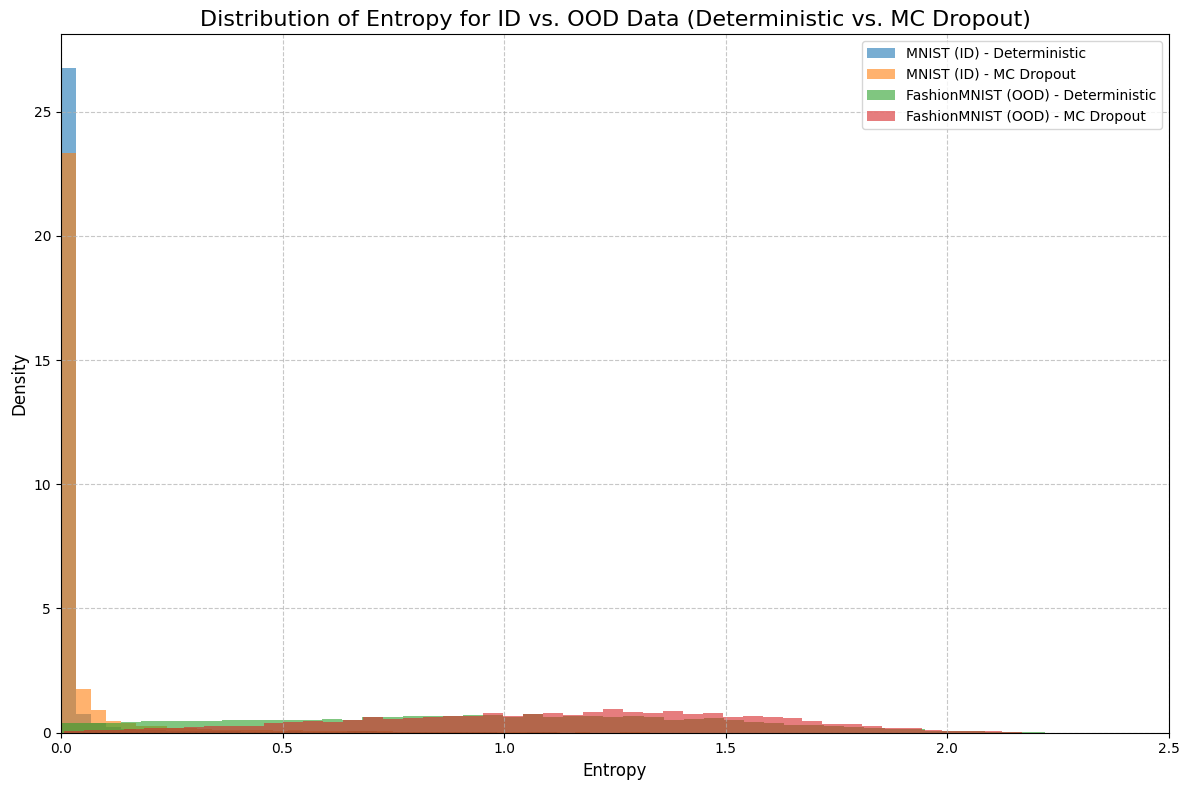

Entropy distribution histogram generated successfully.


In [ ]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
plt.figure(figsize=(12, 8))

bins = 50 # Using a suitable number of bins

# Plot histogram of mnist_entropies (deterministic ID data)
plt.hist(mnist_entropies, bins=bins, alpha=0.6, label='MNIST (ID) - Deterministic', density=True)

# Plot histogram of mnist_mc_entropies (MC Dropout ID data)
plt.hist(mnist_mc_entropies, bins=bins, alpha=0.6, label='MNIST (ID) - MC Dropout', density=True)

# Plot histogram of fashion_entropies (deterministic OOD data)
plt.hist(fashion_entropies, bins=bins, alpha=0.6, label='FashionMNIST (OOD) - Deterministic', density=True)

# Plot histogram of fashion_mc_entropies (MC Dropout OOD data)
plt.hist(fashion_mc_entropies, bins=bins, alpha=0.6, label='FashionMNIST (OOD) - MC Dropout', density=True)

# Add title and labels
plt.title('Distribution of Entropy for ID vs. OOD Data (Deterministic vs. MC Dropout)', fontsize=16)
plt.xlabel('Entropy', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add a legend
plt.legend(fontsize=10)

# Set x-axis limits. Max possible entropy for 10 classes is log(10) approx 2.3.
plt.xlim(0, 2.5)

# Enable grid
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

print("Entropy distribution histogram generated successfully.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_reliability_data(confidences, is_correct_flags, num_bins=10):
    """
    Calculates data points for a reliability diagram.

    Args:
        confidences (np.array): Model's predicted confidences (max probabilities).
        is_correct_flags (np.array): Boolean array indicating if the prediction was correct.
        num_bins (int): Number of bins to divide the confidence range [0, 1] into.

    Returns:
        tuple: (mean_predicted_value_per_bin, fraction_of_positives_per_bin)
    """
    bin_edges = np.linspace(0, 1, num_bins + 1)
    mean_predicted_value_per_bin = []
    fraction_of_positives_per_bin = []

    for i in range(num_bins):
        # Define the lower and upper bounds for the current bin
        lower_bound = bin_edges[i]
        upper_bound = bin_edges[i+1]

        # Find samples that fall into the current bin
        # Upper bound is inclusive for the last bin to handle confidences of 1.0
        if i == num_bins - 1:
            bin_indices = np.where((confidences >= lower_bound) & (confidences <= upper_bound))
        else:
            bin_indices = np.where((confidences >= lower_bound) & (confidences < upper_bound))

        # Get confidences and correctness flags for samples in this bin
        bin_confidences = confidences[bin_indices]
        bin_is_correct = is_correct_flags[bin_indices]

        if len(bin_confidences) > 0:
            mean_predicted_value_per_bin.append(np.mean(bin_confidences))
            fraction_of_positives_per_bin.append(np.mean(bin_is_correct))

    return np.array(mean_predicted_value_per_bin), np.array(fraction_of_positives_per_bin)

print("calculate_reliability_data function defined.")

calculate_reliability_data function defined.


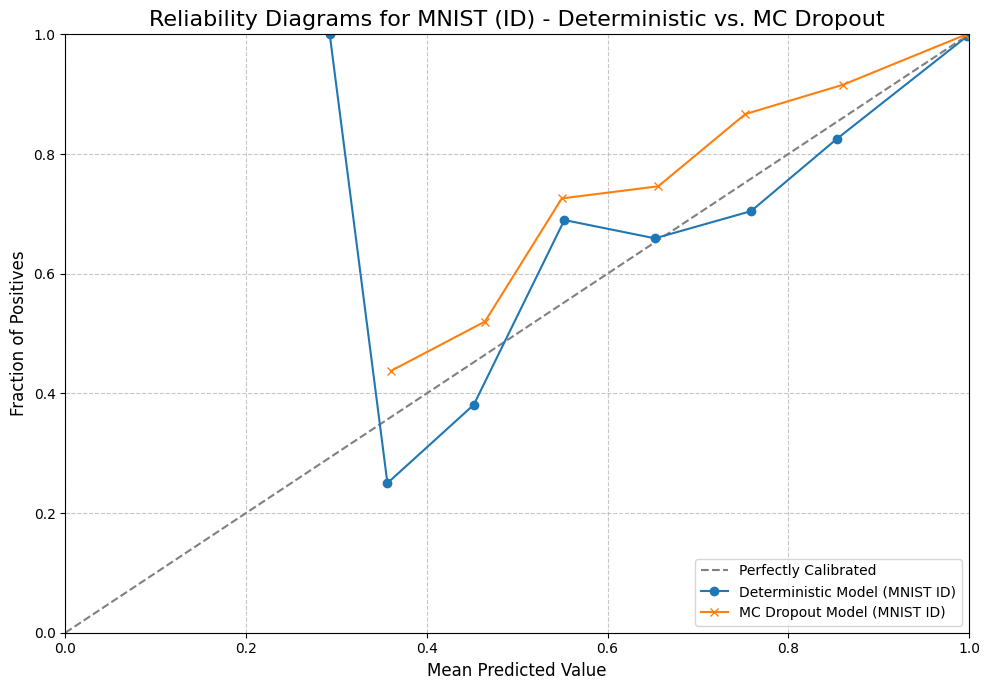

Reliability diagrams generated successfully for MNIST (ID) data.


In [ ]:
import torch.nn.functional as F

# Get true labels for MNIST test data
mnist_true_labels = mnist_test_dataset.targets.cpu().numpy()

# --- Deterministic Model Reliability Data ---
# Determine correctness of deterministic predictions
# We need the predicted classes from the deterministic model for correctness calculation
# mnist_predictions already contains these
correct_deterministic = (mnist_predictions == mnist_true_labels)

# Calculate reliability data for deterministic model
mean_pred_det, frac_pos_det = calculate_reliability_data(mnist_confidences, correct_deterministic)

# --- MC Dropout Model Reliability Data ---
# Determine predicted classes from MC Dropout mean probabilities
# The mean_probabilities from MC Dropout are stored in mnist_mc_mean_probs
mc_dropout_predictions = np.argmax(mnist_mc_mean_probs, axis=1)

# Determine correctness of MC Dropout predictions
correct_mc_dropout = (mc_dropout_predictions == mnist_true_labels)

# Calculate reliability data for MC Dropout model
mean_pred_mc, frac_pos_mc = calculate_reliability_data(mnist_mc_confidences, correct_mc_dropout)

# --- Plotting the Reliability Diagrams ---
plt.figure(figsize=(10, 7))

# Plot the perfectly calibrated line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Plot deterministic model's reliability curve
plt.plot(mean_pred_det, frac_pos_det, marker='o', label='Deterministic Model (MNIST ID)')

# Plot MC Dropout model's reliability curve
plt.plot(mean_pred_mc, frac_pos_mc, marker='x', label='MC Dropout Model (MNIST ID)')

# Add title and labels
plt.title('Reliability Diagrams for MNIST (ID) - Deterministic vs. MC Dropout', fontsize=16)
plt.xlabel('Mean Predicted Value', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Reliability diagrams generated successfully for MNIST (ID) data.")

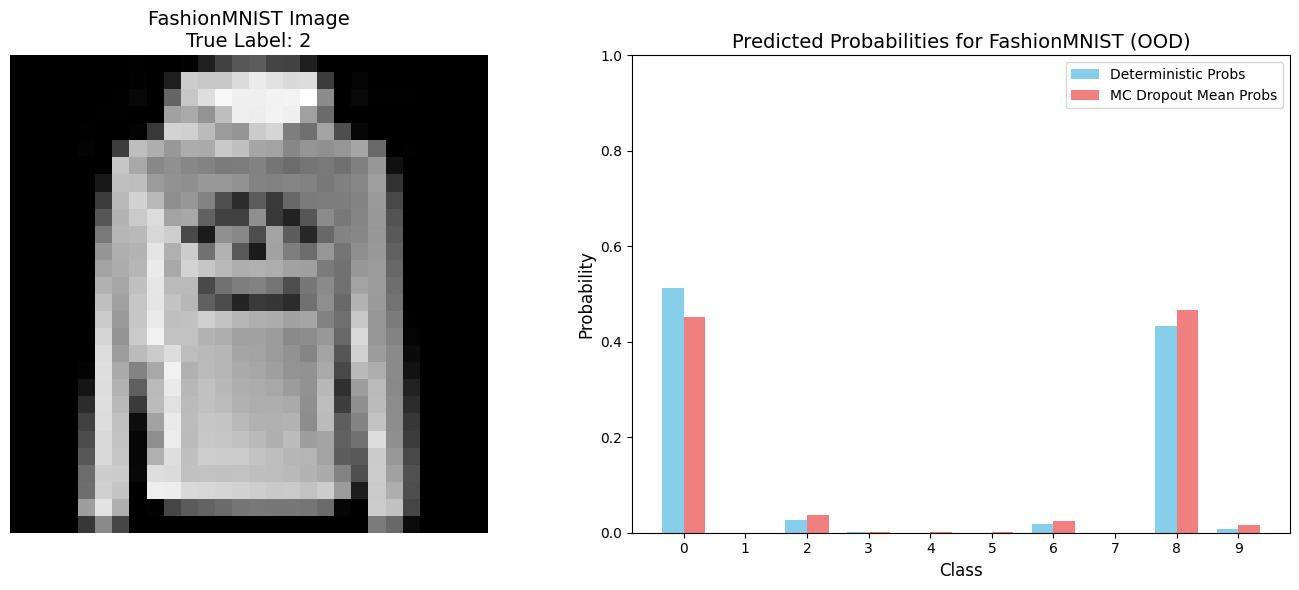

Displaying probability distributions for FashionMNIST image at index 4064.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# 1. Set the model to evaluation mode
# This ensures dropout is turned off for deterministic prediction
model.eval()

# 2. Select a random index for a FashionMNIST test image
random_idx = np.random.randint(0, len(fashion_mnist_test_dataset))

# 3. Retrieve the image and its corresponding true label
image, true_label = fashion_mnist_test_dataset[random_idx]

# 4. Perform a forward pass on the selected image with the model in evaluation mode
# Add a batch dimension to the image (1, 1, 28, 28) and move to device
image_for_model = image.unsqueeze(0).to(device)

with torch.no_grad():
    deterministic_output = model(image_for_model)
    deterministic_probs = F.softmax(deterministic_output, dim=1).cpu().numpy().flatten()

# 5. Retrieve the mean predictive probability distribution for the selected image from the fashion_mc_mean_probs array
mc_dropout_mean_probs = fashion_mc_mean_probs[random_idx]

# 6. Create a Matplotlib figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 7. In the first subplot, display the selected FashionMNIST image
axes[0].imshow(image.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title(f'FashionMNIST Image\nTrue Label: {true_label}', fontsize=14)
axes[0].axis('off') # Hide axes for the image

# 8. In the second subplot, create two bar charts side-by-side
class_labels = np.arange(10) # 0-9 for 10 classes
bar_width = 0.35

# Deterministic probabilities bar chart
rects1 = axes[1].bar(class_labels - bar_width/2, deterministic_probs, bar_width, label='Deterministic Probs', color='skyblue')

# MC Dropout mean predictive probabilities bar chart
rects2 = axes[1].bar(class_labels + bar_width/2, mc_dropout_mean_probs, bar_width, label='MC Dropout Mean Probs', color='lightcoral')

# 9. Add class labels (0-9) to the x-axis for both bar charts
axes[1].set_xticks(class_labels)
axes[1].set_xlabel('Class', fontsize=12)

# 10. Add appropriate titles and axis labels to both plots
axes[1].set_title('Predicted Probabilities for FashionMNIST (OOD)', fontsize=14)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_ylim(0, 1) # Probabilities range from 0 to 1

# 11. Add a legend to the bar chart
axes[1].legend(fontsize=10)

# 12. Display the entire figure to visualize the comparison
plt.tight_layout()
plt.show()

print(f"Displaying probability distributions for FashionMNIST image at index {random_idx}.")

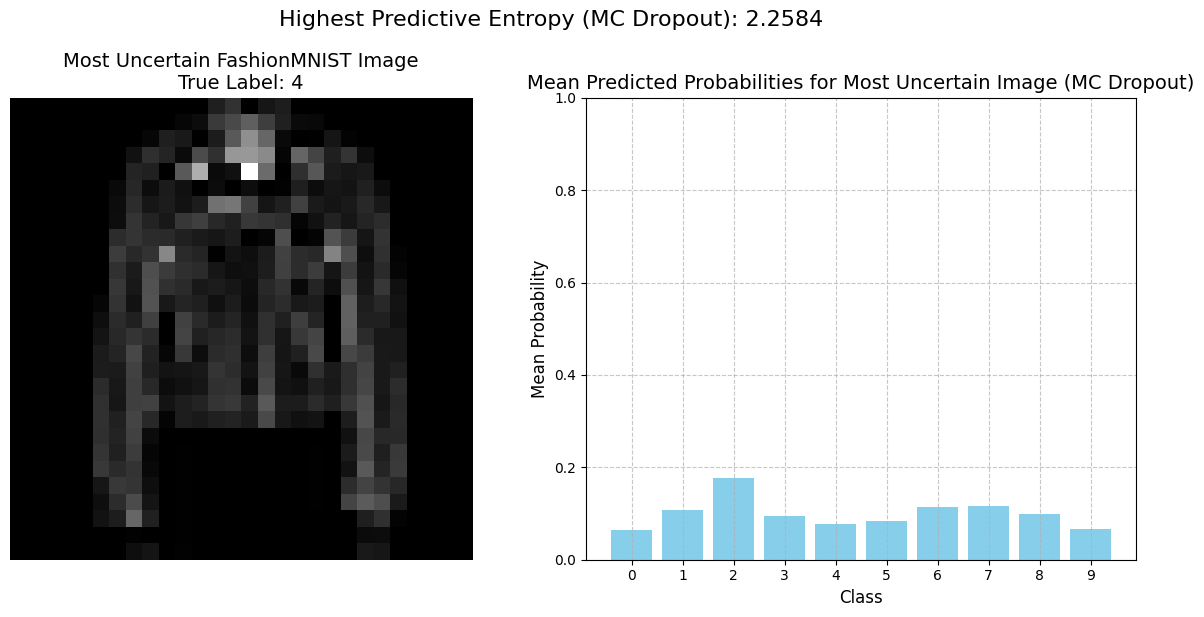

Visualized the most uncertain FashionMNIST image (index: 1243) with a Predictive Entropy of 2.2584.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Find the index of the image with the maximum Predictive Entropy
most_uncertain_idx = np.argmax(fashion_mc_entropies)

# 2. Retrieve the image and its corresponding true label
most_uncertain_image, true_label = fashion_mnist_test_dataset[most_uncertain_idx]

# 3. Extract the mean predictive probabilities for this image
most_uncertain_probs = fashion_mc_mean_probs[most_uncertain_idx]

# 4. Extract the highest predictive entropy value
highest_entropy = fashion_mc_entropies[most_uncertain_idx]

# 5. Create a Matplotlib figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 6. In the first subplot, display the selected FashionMNIST image
axes[0].imshow(most_uncertain_image.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title(f'Most Uncertain FashionMNIST Image\nTrue Label: {true_label}', fontsize=14)
axes[0].axis('off') # Hide axes for the image

# 7. In the second subplot, create a bar chart of mean predicted probabilities
class_labels = np.arange(10) # 0-9 for 10 classes
axes[1].bar(class_labels, most_uncertain_probs, color='skyblue')
axes[1].set_xticks(class_labels)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Mean Probability', fontsize=12)
axes[1].set_title('Mean Predicted Probabilities for Most Uncertain Image (MC Dropout)', fontsize=14)
axes[1].set_ylim(0, 1) # Probabilities range from 0 to 1

# 8. Add the entropy value as an annotation
fig.suptitle(f'Highest Predictive Entropy (MC Dropout): {highest_entropy:.4f}', fontsize=16, y=1.02)

# 9. Add a grid to the bar chart, and ensure proper layout
axes[1].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Visualized the most uncertain FashionMNIST image (index: {most_uncertain_idx}) with a Predictive Entropy of {highest_entropy:.4f}.")

# Conclusion:
The results demonstrate that while the deterministic model is accurate, it is "overconfident" on OOD data (FashionMNIST). In contrast, MC Dropout significantly increases the Predictive Entropy for OOD samples. This confirms that probabilistic deep learning provides a much better mechanism for a model to say "I don't know" when encountering unfamiliar inputs.